# Notebook para simular lentes con imágenes!

Primero, corre esta celda. Se va a tomar un rato en correr. Después, te va a pedir reiniciar (le das que si), y cuando quede, vuelves a correr esta celda (ya no te va a pedir reiniciar)

In [ ]:
%pip install astropy
%pip install "astropy[recommended]"
%pip install caustics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.5/100.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━ 10

In [2]:
import caustics
from caustics import Module, forward
import numpy as np
import torch
from typing import Optional
from copy import copy
from scipy.fft import next_fast_len
from numpy.typing import NDArray
from torch.func import vmap, jacrev
import os
import h5py
from typing import Literal
from ipywidgets import interact, FloatSlider, Layout, interactive_output
import ipywidgets as w
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def make_slider(val, vmin, vmax, step, desc):
    s = w.FloatSlider(value=val, min=vmin, max=vmax, step=step,
                      description=desc,
                      readout=True)
    s.style.description_width = '125px'
    return s

Para subir tu propia imágen:
1. Cambial el nombre a `imagen.jpg`
2. En el notebook, en la columna del lado izquierdo 👈, da click en el símbolo de carpeta 📂
3. Da click en el botón con una flecha hacia arriba ⬆
4. Selecciona el archivo `imagen.jpg` para subirla.

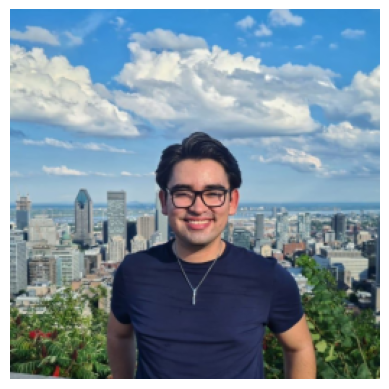

In [9]:
# Cargar imágen
from PIL import Image
img = Image.open('imagen.jpg')

# Convertir en numpy
img = np.asarray(img)

# Downsample to 256 x 256
from skimage.transform import resize
img = resize(img, (256, 256), anti_aliasing=True)

plt.imshow(img)
plt.axis('off')
plt.show()

In [10]:
class SimpleSimulator(Module):
    def __init__(
        self,
        name = "SimpleSimulator",
        source_pixels: int = 256,
        observation_pixels: int = 512,
        observation_fov: float = 12,
        source_fov: float = 8,
        upsample=2,
        z_l: float = 0.5,
        z_s: float = 1.0,
        psf_sigma = None,
        sigma_n = None,
        poisson_rate = None,
        include_lens_light = False,
    ):
        super().__init__()

        self.source_fov = source_fov
        self.observation_fov = observation_fov
        self.source_pixels = source_pixels
        self.observation_pixels = observation_pixels
        self.cosmo = caustics.FlatLambdaCDM(name="cosmo")
        self.source_pixelscale = self.source_fov / self.source_pixels
        self.observation_pixelscale = self.observation_fov / self.observation_pixels
        self.upsample = upsample
        self.psf_sigma = psf_sigma
        self.sigma_n = sigma_n
        self.poisson_rate = poisson_rate
        self.include_lens_light = include_lens_light

        self.lens_epl = caustics.EPL(cosmology=self.cosmo, name="epl")
        self.lens = caustics.SinglePlane(
            name="lensmass", cosmology=self.cosmo, lenses=[self.lens_epl]
        )
        self.source = caustics.Pixelated(
            pixelscale=self.source_pixelscale,
            shape=(source_pixels, source_pixels),
            name="source", x0=0.0, y0=0.0
        )
        thx, thy = caustics.utils.meshgrid(
            self.observation_pixelscale / self.upsample,
            self.upsample * observation_pixels,
            dtype=torch.float32,
            device=DEVICE,
        )
        self.thx = thx.to(DEVICE)
        self.thy = thy.to(DEVICE)
        self.lens.z_l = z_l
        self.lens.z_s = z_s

        if self.include_lens_light:
            self.lens_light = caustics.Pixelated(
                pixelscale=self.observation_pixelscale,
                shape=(observation_pixels, observation_pixels),
                name="lenslight",
                x0=0.0, y0=0.0
            )

    @forward
    def __call__(self):
        # Ray-trace to get the lensed positions
        bx, by = self.lens.raytrace(self.thx, self.thy)

        # Evaluate the lensed source brightness at high resolution
        image = self.source.brightness(bx, by)

        if self.psf_sigma is not None:
            mu_convolved = torch.tensor(gaussian_filter(image.cpu().numpy(), sigma=self.psf_sigma*self.upsample))
        else:
            mu_convolved = image

        # Downsample to the desired resolution
        image_ds = (
            torch.nn.functional.avg_pool2d(mu_convolved.unsqueeze(0), self.upsample)
            .squeeze(0)
            .to(DEVICE)
        )
        if self.include_lens_light:
            mu = self.lens_light.brightness(self.thx, self.thy)
            mu = (
                torch.nn.functional.avg_pool2d(mu.unsqueeze(0), self.upsample)
                .squeeze(0)
                .to(DEVICE)
            )
            # Convolve psf
            mu_convolved = torch.tensor(gaussian_filter(mu.cpu().numpy(), sigma=self.psf_sigma*self.upsample))
            image_ds += mu_convolved
        if self.poisson_rate is not None:
            image_ds = torch.poisson((image_ds+image_ds.min()+1e-3) * self.poisson_rate) / self.poisson_rate
        if self.sigma_n is not None:
            image_ds += torch.randn_like(image_ds) * self.sigma_n

        return image_ds

In [18]:
cosmology = caustics.FlatLambdaCDM()

# Tamaño de la imagen
obs_fov = 12
source_fov = 8

# Resolución de la imagen
obs_pixels = 512
source_pixels = 256

# Creamos matrices de pixeles
pixelscale_source = source_fov / source_pixels
thx_source, thy_source = caustics.utils.meshgrid(pixelscale_source, source_pixels, source_pixels)

pixelscale_obs = obs_fov / obs_pixels
thx_obs, thy_obs = caustics.utils.meshgrid(pixelscale_obs, obs_pixels, obs_pixels)

In [64]:
# -----  Lens (SIE) sliders  -----
x0_lens  = make_slider(-0.2, -1, 1, .01, r'x₀ lente')
y0_lens  = make_slider( 0.0, -1, 1, .01, r'y₀ lente')
q_lens   = make_slider( 0.7,  .1, 1, .01, 'Eje lente')
phi_lens = make_slider( 1.57, -3.14, 3.14, .01, 'Orient. lente')
Rein     = make_slider( 1.7,  .1, 5,  .1,  'Rₑ Einstein')

lens_box = w.GridBox(children=[x0_lens, y0_lens, q_lens, phi_lens, Rein],
                     layout=Layout(grid_template_columns='repeat(2, 240px)',
                                   grid_gap='6px 10px'))

# -----  Lens-light sliders  -----
n_L   = make_slider(1.0, 0.5, 3, .1, 'Índice luz lente')
Re_L  = make_slider(1.0, 0.1, 5, .1, 'Rₑ luz lente')

light_box = w.GridBox(children=[n_L, Re_L],
                      layout=lens_box.layout)
ui = w.Accordion(children=[lens_box])
ui.set_title(0, 'Lente (SIE)')
ui.set_title(1, 'Fuente')
ui.set_title(2, 'Luz del lente')


# -------------------------------------------------
# 3.  Plotting callback (unchanged physics code)
# -------------------------------------------------
def plot_lens_source(**p):

    source_pixelscale = 8 / 256
    src = caustics.Pixelated(
            pixelscale=source_pixelscale,
            shape=(256, 256),
            name="source", x0 = 0, y0 = 0
        )

    # CAMBIAR SOURCE
    sie = caustics.SIE(cosmology=cosmology,
                       name="lens", z_l=0.5, z_s=1.0,
                       x0=p['x0_lens'], y0=p['y0_lens'],
                       q=p['q_lens'],  phi=p['phi_lens'],
                       Rein=p['Rein'])

    sim = caustics.LensSource(lens=sie, source=src,
                              pixelscale=pixelscale_obs, pixels_x=obs_pixels)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img, cmap='inferno')
    ax[0].set_title('Perfil de Luz de la Fuente'); ax[0].axis('off')

    ax[1].imshow(torch.log(sie.convergence(thx_obs, thy_obs)))
    ax[1].set_title('Log-Convergencia de la lente'); ax[1].axis('off')

    lens_channel = []
    for i in range(3):
        lens = sim(torch.tensor(img[:,:,i]).flatten())
        lens_channel.append(lens.cpu().numpy())
    lens_final = np.stack(lens_channel, axis=0).transpose(1, 2, 0)
    print(lens_final.shape)

    ax[2].imshow(lens_final)
    ax[2].set_title('Imagen de la lente'); ax[2].axis('off')
    plt.show()

# -------------------------------------------------
# 4.  Link widgets → callback and display
# -------------------------------------------------
controls = dict(x0_lens=x0_lens, y0_lens=y0_lens, q_lens=q_lens,
                phi_lens=phi_lens, Rein=Rein,
                n_L=n_L, Re_L=Re_L)

out = interactive_output(plot_lens_source, controls)

display(ui, out)


Accordion(children=(GridBox(children=(FloatSlider(value=-0.2, description='x₀ lente', max=1.0, min=-1.0, step=…

Output()

Ejemplo:

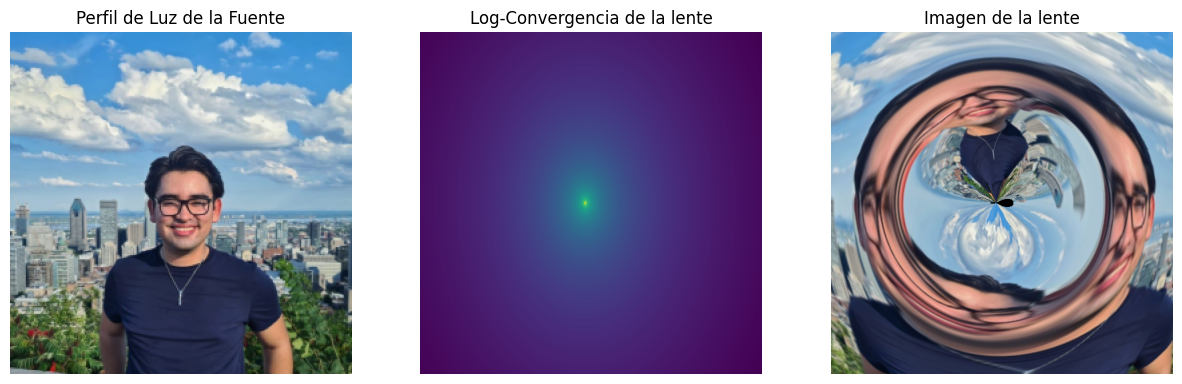